In [1]:
import sys
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_loader import load_stock_data
from src.visualizer import plot_daily_candlestick
from src.features import create_features
from src.risk_manager import evaluate_trade_risk
from src.label import create_labels

In [2]:
# Set tanggal dinamis (Contoh: Menarik data dari 6 bulan lalu hingga hari ini)
hari_ini = datetime.now().strftime('%Y-%m-%d')
enam_bulan_lalu = (datetime.now() - timedelta(days=180)).strftime('%Y-%m-%d')

# 1. Panggil data BUMI riil dari Bursa Efek Indonesia (.JK)
# Data ini mencerminkan kondisi pasar riil per Juni 2026
df_bumi = load_stock_data(ticker="BUMI.JK", start_date=enam_bulan_lalu, end_date=hari_ini)
# ------------------------------------------

Mengunduh data terbaru untuk BUMI.JK dari Yahoo Finance...
Berhasil memuat 113 baris data untuk BUMI.JK.
Info Data Cleaning: Menghapus 4 baris data (NaN atau Volume 0).
Berhasil memuat 109 baris data bersih untuk BUMI.JK.


In [3]:
print(df_bumi)

             Open   High    Low  Close        Volume
Date                                                
2025-12-23  402.0  406.0  376.0  380.0  8.335353e+09
2025-12-24  382.0  384.0  360.0  362.0  4.795205e+09
2025-12-29  362.0  376.0  354.0  366.0  5.492663e+09
2025-12-30  370.0  372.0  362.0  366.0  2.812870e+09
2026-01-02  372.0  424.0  370.0  420.0  1.177109e+10
...           ...    ...    ...    ...           ...
2026-06-15  165.0  191.0  163.0  173.0  1.333560e+10
2026-06-17  175.0  178.0  165.0  168.0  4.078183e+09
2026-06-18  169.0  173.0  163.0  171.0  2.760389e+09
2026-06-19  172.0  177.0  167.0  168.0  2.642491e+09
2026-06-21    NaN    NaN    NaN    NaN           NaN

[110 rows x 5 columns]


Menghasilkan grafik candlestick untuk BUMI...


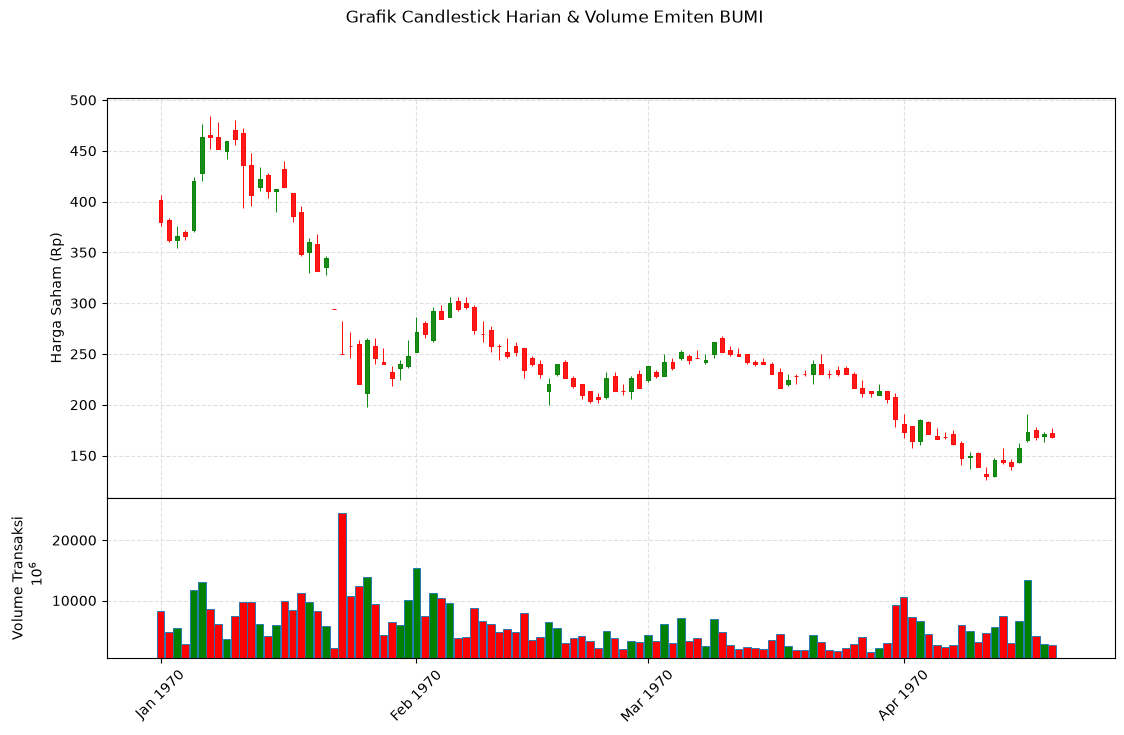

In [4]:
plot_daily_candlestick(df=df_bumi, ticker_name="BUMI")

In [5]:
# df_bumi = calculate_atr(df_bumi)
# latest_data = df_bumi.iloc[-1]
# current_close = float(latest_data['Close'])
# current_atr = float(latest_data['ATR'])

# resisten_terdekat = 186.0  

# trade_analysis = evaluate_trade_risk(
#     entry_price=current_close,
#     atr=current_atr,
#     resistance_level=resisten_terdekat,
#     min_rr_ratio=2.0
# )

# # Cetak Hasil Validasi Hitam-di-Atas-Putih
# print("=== LIVE SYSTEM RISK EVALUATION ===")
# print(f"Harga Masuk Terkini     : Rp{trade_analysis['entry_price']}")
# print(f"Nilai Volatilitas (ATR) : Rp{round(current_atr, 2)}")
# print(f"Garis Aman Cut Loss (SL): Rp{trade_analysis['suggested_stop_loss']} (Terproteksi dari noise)")
# print(f"Target Resisten (TP)    : Rp{trade_analysis['target_profit_resistance']}")
# print(f"Rasio R-to-R Aktual     : {trade_analysis['actual_rr_ratio']}x")
# print("-----------------------------------")

# if trade_analysis['execute_trade']:
#     print("KEPUTUSAN SISTEM: ISI ORDER BELI! Matematika risiko mendukung penuh.")
# else:
#     print("KEPUTUSAN SISTEM: BLOKIR TRANSAKSI! Jarak ke resisten terlalu sempit, batalkan emosi Anda.")

## ADD LABELS & FEATURES

In [6]:
HORIZON = 5

df_bumi = load_stock_data(ticker="BUMI.JK", start_date=enam_bulan_lalu, end_date=hari_ini)
df_bumi = create_labels(df_bumi, HORIZON)
df_bumi = create_features(df_bumi)
df_bumi

Mengunduh data terbaru untuk BUMI.JK dari Yahoo Finance...
Berhasil memuat 113 baris data untuk BUMI.JK.
Info Data Cleaning: Menghapus 4 baris data (NaN atau Volume 0).
Berhasil memuat 109 baris data bersih untuk BUMI.JK.


,Open,High,Low,Close,Volume,trend_slope,return,risk,days_to_max,days_to_min,...,max,min,ATR,RSI,Volume_Ratio,Log_Return,Support_Zone_Low,Support_Zone_High,Resistance_Zone_Low,Resistance_Zone_High
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-23,402.0,406.0,376.0,380.0,8.335353e+09,8.4,0.054726,-0.119403,5.0,3.0,...,424.0,354.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-24,382.0,384.0,360.0,362.0,4.795205e+09,25.8,0.246073,-0.073298,5.0,2.0,...,476.0,354.0,30.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-29,362.0,376.0,354.0,366.0,5.492663e+09,29.4,0.337017,-0.022099,5.0,1.0,...,484.0,354.0,29.200000,0.000000,NaN,-0.048527,NaN,NaN,NaN,NaN
2025-12-30,370.0,372.0,362.0,366.0,2.812870e+09,21.6,0.308108,-0.021622,4.0,1.0,...,484.0,362.0,28.240000,20.408163,NaN,0.010989,NaN,NaN,NaN,NaN
2026-01-02,372.0,424.0,370.0,420.0,1.177109e+10,6.8,0.301075,-0.005376,3.0,1.0,...,484.0,370.0,25.808000,20.408163,NaN,0.000000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-15,165.0,191.0,163.0,173.0,1.333560e+10,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,16.158023,49.061083,1.359440,0.114603,126.0,134.079012,215.920988,224.0
2026-06-17,175.0,178.0,165.0,168.0,4.078183e+09,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,18.536953,59.884443,2.494476,0.097046,126.0,135.268477,210.731523,220.0
2026-06-18,169.0,173.0,163.0,171.0,2.760389e+09,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,17.798693,55.622927,0.745104,-0.029328,126.0,134.899346,211.100654,220.0


In [7]:
df_bumi.head(10)

,Open,High,Low,Close,Volume,trend_slope,return,risk,days_to_max,days_to_min,...,max,min,ATR,RSI,Volume_Ratio,Log_Return,Support_Zone_Low,Support_Zone_High,Resistance_Zone_Low,Resistance_Zone_High
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-23,402.0,406.0,376.0,380.0,8.335353e+09,8.4,0.054726,-0.119403,5.0,3.0,...,424.0,354.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-24,382.0,384.0,360.0,362.0,4.795205e+09,25.8,0.246073,-0.073298,5.0,2.0,...,476.0,354.0,30.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-29,362.0,376.0,354.0,366.0,5.492663e+09,29.4,0.337017,-0.022099,5.0,1.0,...,484.0,354.0,29.200000,0.000000,NaN,-0.048527,NaN,NaN,NaN,NaN
2025-12-30,370.0,372.0,362.0,366.0,2.812870e+09,21.6,0.308108,-0.021622,4.0,1.0,...,484.0,362.0,28.240000,20.408163,NaN,0.010989,NaN,NaN,NaN,NaN
2026-01-02,372.0,424.0,370.0,420.0,1.177109e+10,6.8,0.301075,-0.005376,3.0,1.0,...,484.0,370.0,25.808000,20.408163,NaN,0.000000,NaN,NaN,NaN,NaN
2026-01-05,428.0,476.0,420.0,464.0,1.304842e+10,-0.8,0.130841,-0.018692,2.0,1.0,...,484.0,420.0,30.100267,82.949607,NaN,0.137621,NaN,NaN,NaN,NaN
2026-01-06,466.0,484.0,452.0,464.0,8.648117e+09,-4.6,0.038627,-0.154506,1.0,5.0,...,484.0,394.0,33.553564,90.193962,NaN,0.099630,NaN,NaN,NaN,NaN
2026-01-07,464.0,478.0,452.0,452.0,6.102514e+09,-11.6,0.034483,-0.150862,3.0,4.0,...,480.0,394.0,33.346423,90.193962,NaN,0.000000,NaN,NaN,NaN,NaN
2026-01-08,450.0,460.0,442.0,460.0,3.629921e+09,-13.2,0.066667,-0.124444,2.0,3.0,...,480.0,394.0,32.366900,78.139199,NaN,-0.026202,NaN,NaN,NaN,NaN


In [8]:
df_bumi.tail(10)

,Open,High,Low,Close,Volume,trend_slope,return,risk,days_to_max,days_to_min,...,max,min,ATR,RSI,Volume_Ratio,Log_Return,Support_Zone_Low,Support_Zone_High,Resistance_Zone_Low,Resistance_Zone_High
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-08,132.0,139.0,126.0,130.0,4.621182e+09,4.8,0.227273,-0.045455,5.0,1.0,...,162.0,126.0,16.002518,19.877837,0.749406,-0.076161,137.0,145.001259,241.998741,250.0
2026-06-09,130.0,148.0,129.0,146.0,5.625440e+09,6.7,0.469231,-0.007692,5.0,1.0,...,191.0,129.0,15.602182,17.077440,1.111615,-0.066939,126.0,133.801091,230.198909,238.0
2026-06-10,146.0,157.0,142.0,144.0,7.438604e+09,8.1,0.308219,-0.068493,4.0,2.0,...,191.0,136.0,16.055224,35.668345,1.292543,0.116072,126.0,134.027612,229.972388,238.0
2026-06-11,144.0,147.0,136.0,140.0,2.994048e+09,7.3,0.326389,-0.055556,3.0,1.0,...,191.0,136.0,15.914528,34.551102,1.601539,-0.013793,126.0,133.957264,230.042736,238.0
2026-06-12,144.0,162.0,143.0,157.0,6.630660e+09,2.0,0.326389,-0.006944,2.0,1.0,...,191.0,143.0,15.259257,32.221967,0.638560,-0.028171,126.0,133.629629,224.370371,232.0
2026-06-15,165.0,191.0,163.0,173.0,1.333560e+10,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,16.158023,49.061083,1.359440,0.114603,126.0,134.079012,215.920988,224.0
2026-06-17,175.0,178.0,165.0,168.0,4.078183e+09,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,18.536953,59.884443,2.494476,0.097046,126.0,135.268477,210.731523,220.0
2026-06-18,169.0,173.0,163.0,171.0,2.760389e+09,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,17.798693,55.622927,0.745104,-0.029328,126.0,134.899346,211.100654,220.0
2026-06-19,172.0,177.0,167.0,168.0,2.642491e+09,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,16.758867,57.706565,0.501607,0.017700,126.0,134.379434,205.620566,214.0


In [10]:
feature_cols = ['ATR', 'RSI', 'Volume_Ratio', 'Log_Return', 'Support_Zone_Low', 'Support_Zone_High', 'Resistance_Zone_Low', 'Resistance_Zone_High']
label_cols = ['trend_slope', 'return', 'risk', 'days_to_max', 'days_to_min']

# Satukan ke dalam satu dataset besar
df_bumi = df_bumi.dropna()
X = df_bumi[feature_cols]
y = df_bumi[label_cols]

print(f"Dataset pelatihan siap! X: {X.shape}, y: {y.shape}")

Dataset pelatihan siap! X: (85, 8), y: (85, 5)
